In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import triangle as tr
 
rng = np.random.default_rng(0)

In [19]:
# 1. 計算領域とメッシュ点の生成（矩形流路 + 円柱）
LX, LY = 3.0, 1.0            # 流路の長さ・高さ
CX, CY, R = 0.8, 0.5, 0.15   # 円柱の中心と半径

def make_points_and_segments():
    """点と境界セグメントを生成（CDT用）"""
    pts = []
    segments = []  # 境界エッジを強制するセグメント
    
    # --- 外周境界 ---
    # inlet (x=0)
    inlet_y = np.linspace(0, LY, 21)
    inlet_start = len(pts)
    for y in inlet_y:
        pts.append((0.0, y))
    # inlet上の連続セグメント
    for i in range(len(inlet_y) - 1):
        segments.append([inlet_start + i, inlet_start + i + 1])
    
    # outlet (x=LX)
    outlet_start = len(pts)
    for y in inlet_y:
        pts.append((LX, y))
    for i in range(len(inlet_y) - 1):
        segments.append([outlet_start + i, outlet_start + i + 1])
    
    # bottom wall (y=0)
    wall_x = np.linspace(0, LX, 61)[1:-1]  # 端点は inlet/outlet と重複
    bottom_start = len(pts)
    for x in wall_x:
        pts.append((x, 0.0))
    # bottom wall セグメント (inlet左下 → bottom点 → outlet右下)
    segments.append([inlet_start, bottom_start])  # inlet左下 → bottom最初
    for i in range(len(wall_x) - 1):
        segments.append([bottom_start + i, bottom_start + i + 1])
    segments.append([bottom_start + len(wall_x) - 1, outlet_start])  # bottom最後 → outlet右下
    
    # top wall (y=LY)
    top_start = len(pts)
    for x in wall_x:
        pts.append((x, LY))
    # top wall セグメント
    segments.append([inlet_start + 20, top_start])  # inlet左上 → top最初
    for i in range(len(wall_x) - 1):
        segments.append([top_start + i, top_start + i + 1])
    segments.append([top_start + len(wall_x) - 1, outlet_start + 20])  # top最後 → outlet右上
    
    # --- 円柱表面 ---
    n_cyl = 20
    cylinder_start = len(pts)
    for th in np.linspace(0, 2 * np.pi, n_cyl, endpoint=False):
        pts.append((CX + R * np.cos(th), CY + R * np.sin(th)))
    # 円柱は閉じたループ
    for i in range(n_cyl):
        segments.append([cylinder_start + i, cylinder_start + (i + 1) % n_cyl])
    
    n_boundary = len(pts)  # 境界点の数
    
    # --- 内部点 ---
    n_trial = 2000
    cand = rng.uniform([0.02, 0.02], [LX - 0.02, LY - 0.02], size=(n_trial, 2))
    d = np.hypot(cand[:, 0] - CX, cand[:, 1] - CY)
    keep = d > R * 1.15
    cand = cand[keep]
    selected = []
    min_dist = 0.06
    for p in cand:
        if all(np.hypot(p[0] - q[0], p[1] - q[1]) > min_dist for q in selected):
            selected.append(tuple(p))
    pts.extend(selected)
    
    return np.array(pts), np.array(segments), n_boundary

In [20]:
pos, segments, n_boundary = make_points_and_segments()
print(f"点数: {len(pos)}, 境界点: {n_boundary}, セグメント数: {len(segments)}")

点数: 559, 境界点: 180, セグメント数: 180


In [21]:
### Constrained Delaunay Triangulation (CDT) ###
# 'p' = PSLG (Planar Straight Line Graph) モード: セグメントを保持
# 円柱内部に穴を開けるため、hole を指定

mesh_input = {
    'vertices': pos,
    'segments': segments,
    'holes': np.array([[CX, CY]])  # 円柱内部に穴
}

mesh = tr.triangulate(mesh_input, 'p')
simplices = mesh['triangles']
print(f"三角形数: {len(simplices)}")

三角形数: 938


In [22]:
# エッジ抽出
edges = set()
for a, b, c in simplices:
    for i, j in ((a, b), (b, c), (c, a)):
        edges.add((min(i, j), max(i, j)))
edges = np.array(sorted(edges))

# GNN用: 双方向エッジ
edge_index = np.concatenate([edges, edges[:, ::-1]]).T
N = len(pos)
E = edge_index.shape[1]
print(f"ノード数: {N}, エッジ数(双方向): {E}")

ノード数: 559, エッジ数(双方向): 2994


/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 12472 (\N{KATAKANA LETTER ZI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_48655/1269361817.py:20: UserWarning: Glyph 35388 (\N{CJK UNIFIED IDEOGRAPH-8A3C}) missing fr

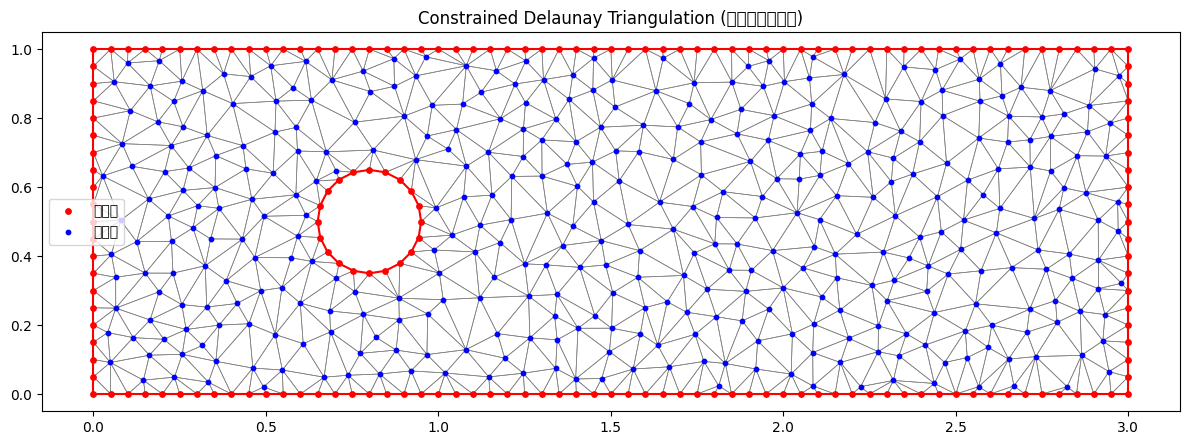

In [23]:
# 可視化: CDTメッシュ
fig, ax = plt.subplots(figsize=(12, 5))

# 三角形を描画
for simplex in simplices:
    triangle = plt.Polygon(pos[simplex], fill=False, edgecolor='gray', linewidth=0.5)
    ax.add_patch(triangle)

# 境界点と内部点を色分け
ax.scatter(pos[:n_boundary, 0], pos[:n_boundary, 1], c='red', s=15, label='境界点', zorder=5)
ax.scatter(pos[n_boundary:, 0], pos[n_boundary:, 1], c='blue', s=10, label='内部点', zorder=5)

# 境界セグメント（強制エッジ）をハイライト
for seg in segments:
    ax.plot(pos[seg, 0], pos[seg, 1], 'r-', linewidth=1.5, zorder=4)

ax.set_aspect('equal')
ax.legend()
ax.set_title('Constrained Delaunay Triangulation (境界エッジ保証)')
plt.tight_layout()
plt.show()

In [27]:
INTERIOR, INLET, OUTLET, WALL = 0, 1, 2, 3
node_type = np.full(N, INTERIOR)
eps = 1e-6
node_type.shape

(559,)